In [27]:
import sys
sys.path.append("/users/xn22103/atmospherics-tools/fast-osc-feedback/")

import polars as pl
import uproot
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt

caf_tree = uproot.open("/storage/1/st15719/caf_new_sum.2.6M_weighted.root")["cafTree"]

Enu_e_had   = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.e_had"
Enu_e_calo  = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.e_calo"
Enu_mu_had  = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.mu_had"
Enu_mu_range= "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.mu_range"
PDG         = "rec/mc/mc.nu/mc.nu.pdg"

caf_data = caf_tree.arrays([Enu_e_had, Enu_e_calo, Enu_mu_had, Enu_mu_range, PDG])

caf_df = pl.from_pandas(ak.to_dataframe(caf_data, how = "outer"))
caf_df.columns = ["Enu_e_had","Enu_e_calo","Enu_mu_had","Enu_mu_range","PDG"]

reco_pfp_tree = uproot.open("reco_pfp_info.root")["reco_pfp_tree"]
reco_pfp_df = pl.from_pandas(reco_pfp_tree.arrays(library="pd"))

data = pl.concat([caf_df, reco_pfp_df], how="horizontal")

data = data.filter(pl.col("reco_ok") == True)


data = data.with_columns(
	( (pl.col("Enu_e_had") / pl.col("Enu_e_calo"))).alias("inelasticity_e"),
	((pl.col("Enu_mu_had") / pl.col("Enu_mu_range"))).alias("inelasticity_mu"),
	(pl.col("PDG") < 0).cast(pl.Int64).alias("label"))



data = data.to_pandas()
data = data.dropna()
data

,Enu_e_had,Enu_e_calo,Enu_mu_had,Enu_mu_range,PDG,reco_ok,n_reco_pfps,n_reco_tracks,n_reco_showers,single_hits_energy,n_reco_muons_pions,n_reco_protons,inelasticity_e,inelasticity_mu,label
0,1.237640e+01,28.432413,28.015844,28.529816,-12,True,10,5,4,11.487990,4,1,4.352918e-01,0.981985,1
1,9.994991e-02,0.208079,0.099950,0.322256,-12,True,2,1,0,0.110940,1,0,4.803471e-01,0.310157,1
2,3.063447e-01,1.156426,0.306345,1.201710,-14,True,4,3,0,0.064570,2,1,2.649064e-01,0.254924,1
3,8.884442e-02,0.502835,0.088844,0.593700,14,True,3,2,0,0.002420,1,1,1.766871e-01,0.149645,0
4,3.318707e-03,0.299485,0.003319,0.299201,16,True,2,1,0,0.003319,1,0,1.108138e-02,0.011092,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2651022,-8.104407e-17,0.156685,0.000000,0.256748,14,True,2,1,0,0.000000,1,0,-5.172407e-16,0.000000,0
2651023,2.552473e-03,0.169946,0.002552,0.260973,14,True,2,1,0,0.005397,1,0,1.501929e-02,0.009781,0
2651024,1.402719e-02,0.124140,0.014027,0.207403,14,True,3,1,1,0.012165,1,0,1.129947e-01,0.067633,0
2651025,5.641751e-02,1.383207,1.343197,1.471067,12,True,3,1,1,0.102556,0,1,4.078746e-02,0.913077,0


In [28]:
plotting_data = data.drop(columns = ['Enu_e_had','Enu_e_calo','Enu_mu_had','Enu_mu_range'])
plotting_data

,PDG,reco_ok,n_reco_pfps,n_reco_tracks,n_reco_showers,single_hits_energy,n_reco_muons_pions,n_reco_protons,inelasticity_e,inelasticity_mu,label
0,-12,True,10,5,4,11.487990,4,1,4.352918e-01,0.981985,1
1,-12,True,2,1,0,0.110940,1,0,4.803471e-01,0.310157,1
2,-14,True,4,3,0,0.064570,2,1,2.649064e-01,0.254924,1
3,14,True,3,2,0,0.002420,1,1,1.766871e-01,0.149645,0
4,16,True,2,1,0,0.003319,1,0,1.108138e-02,0.011092,0
...,...,...,...,...,...,...,...,...,...,...,...
2651022,14,True,2,1,0,0.000000,1,0,-5.172407e-16,0.000000,0
2651023,14,True,2,1,0,0.005397,1,0,1.501929e-02,0.009781,0
2651024,14,True,3,1,1,0.012165,1,0,1.129947e-01,0.067633,0
2651025,12,True,3,1,1,0.102556,0,1,4.078746e-02,0.913077,0


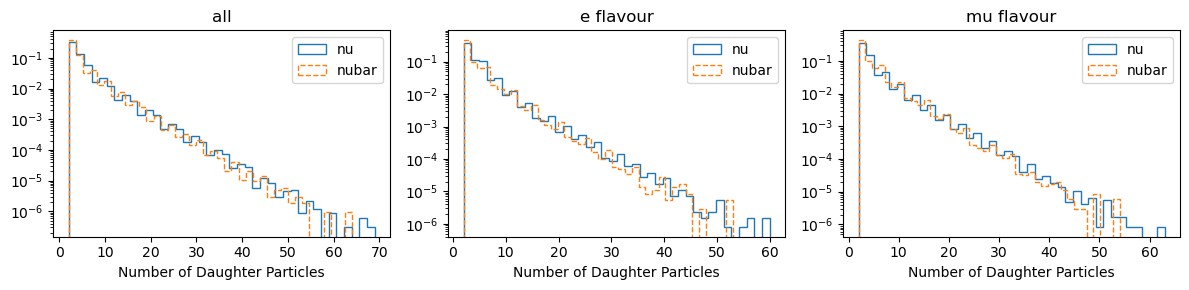

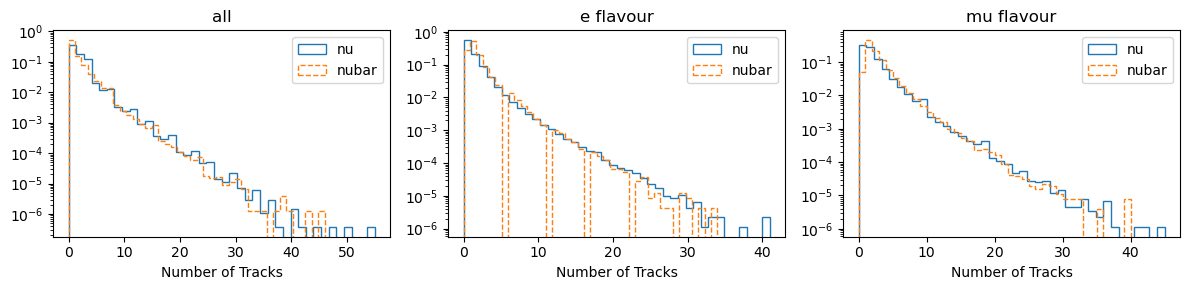

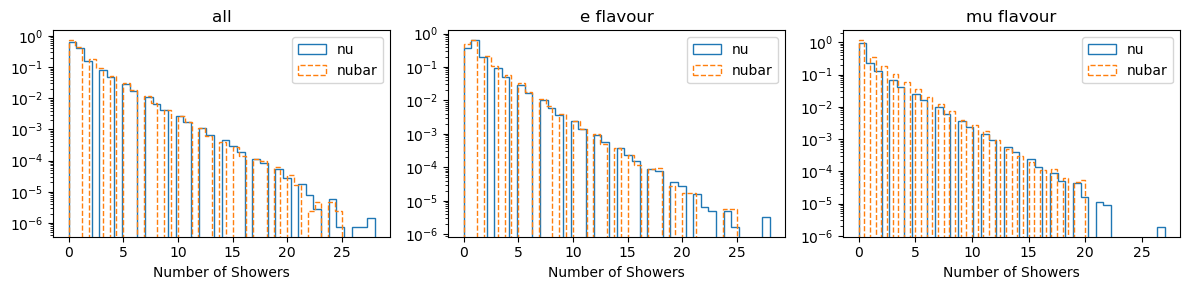

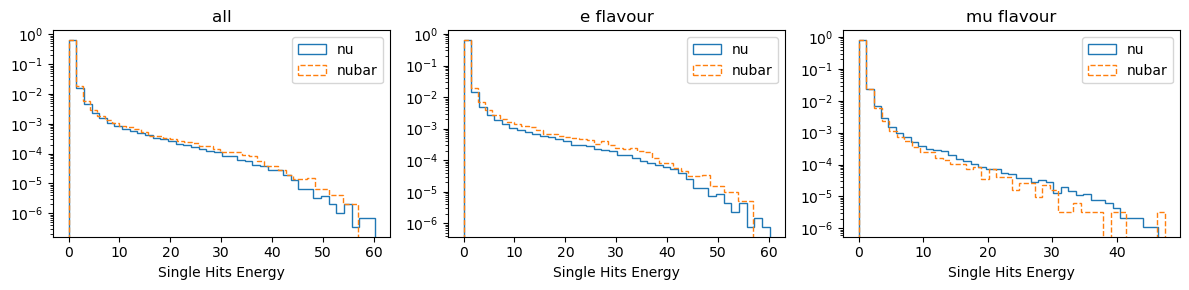

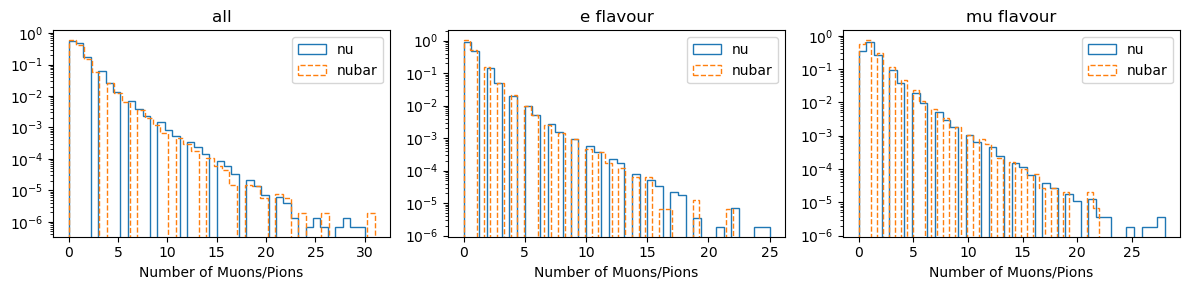

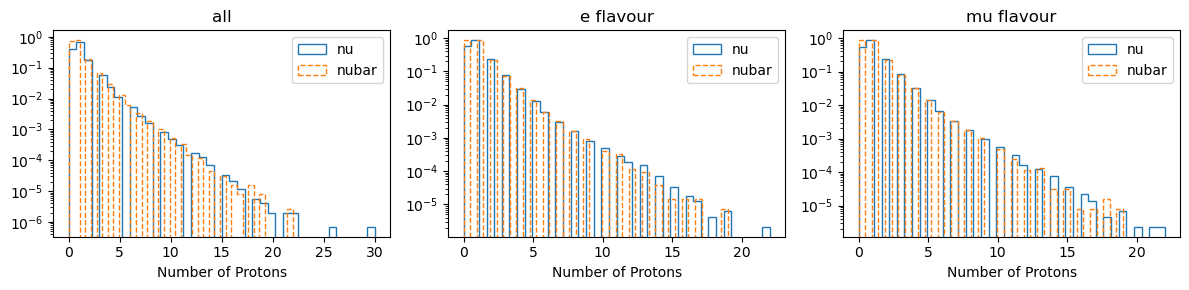

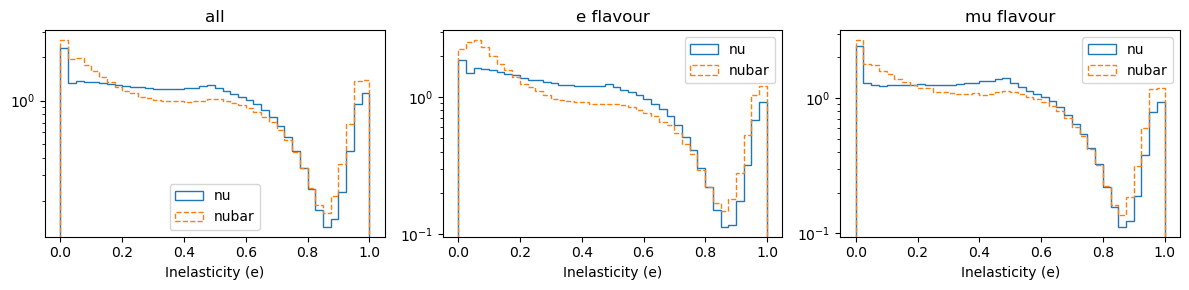

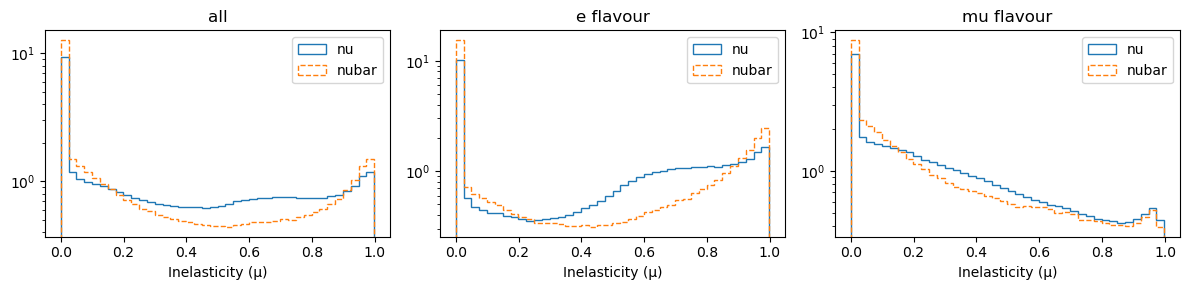

In [29]:
import numpy as np
import matplotlib.pyplot as plt

features = [
	"n_reco_pfps",
	"n_reco_tracks",
	"n_reco_showers",
	"single_hits_energy",
	"n_reco_muons_pions",
	"n_reco_protons",
	"inelasticity_e",
	"inelasticity_mu"
]

label_map = {
    "Enu_e_had": "Hadronic Energy (e)",
    "Enu_e_calo": "Calorimetric Energy (e)",
    "Enu_mu_had": "Hadronic Energy (μ)",
    "Enu_mu_range": "Range-based Energy (μ)",
    "PDG": "True PDG Code",
    "n_reco_pfps": "Number of Daughter Particles",
    "n_reco_tracks": "Number of Tracks",
    "n_reco_showers": "Number of Showers",
    "n_reco_muons_pions": "Number of Muons/Pions",
    "n_reco_protons": "Number of Protons",
    "single_hits_energy": "Single Hits Energy",
    "n_true_nu": "N True Neutrinos",
    "n_primary_daughters": "N Primary Daughters",
    "n_primary_electrons": "N Primary Electrons",
    "n_primary_muons": "N Primary Muons",
    "n_primary_protons": "N Primary Protons",
    "n_primary_pions": "N Primary Pions",
    "n_primary_photons": "N Primary Photons",
    "n_primary_pi0s": "N Primary π⁰s",
    "n_primary_tracks": "N Primary Tracks",
    "n_primary_showers": "N Primary Showers",
    "inelasticity_e": "Inelasticity (e)",
    "inelasticity_mu": "Inelasticity (μ)",
    "inelasticity": "Inelasticity",
}

is_nu = plotting_data["label"] == 0
is_nubar = plotting_data["label"] == 1
is_e = np.abs(plotting_data["PDG"]) == 12
is_mu = np.abs(plotting_data["PDG"]) == 14

for feat in features:
	fig, axes = plt.subplots(1,3, figsize=(12,3))

	axes[0].hist(plotting_data[feat][is_nu], bins=40, density=True, histtype="step", label="nu")
	axes[0].hist(plotting_data[feat][is_nubar], bins=40, density=True, histtype="step", label="nubar", linestyle = "--")
	axes[0].set_title("all")
	# axes[0].set_xscale("log")	
	axes[0].set_yscale("log")

	axes[1].hist(plotting_data[feat][is_nu & is_e], bins=40, density=True, histtype="step", label="nu")
	axes[1].hist(plotting_data[feat][is_nubar & is_e], bins=40, density=True, histtype="step", label="nubar", linestyle="--")
	axes[1].set_title("e flavour")
	# axes[1].set_xscale("log")
	axes[1].set_yscale("log")

	axes[2].hist(plotting_data[feat][is_nu & is_mu], bins=40, density=True, histtype="step", label="nu")
	axes[2].hist(plotting_data[feat][is_nubar & is_mu], bins=40, density=True, histtype="step", label="nubar", linestyle="--")
	axes[2].set_title("mu flavour")
	# axes[2].set_xscale("log")
	axes[2].set_yscale("log")

	for ax in axes:
		ax.legend()
		ax.set_xlabel(label_map.get(feat, feat))

	plt.tight_layout()
	plt.show()


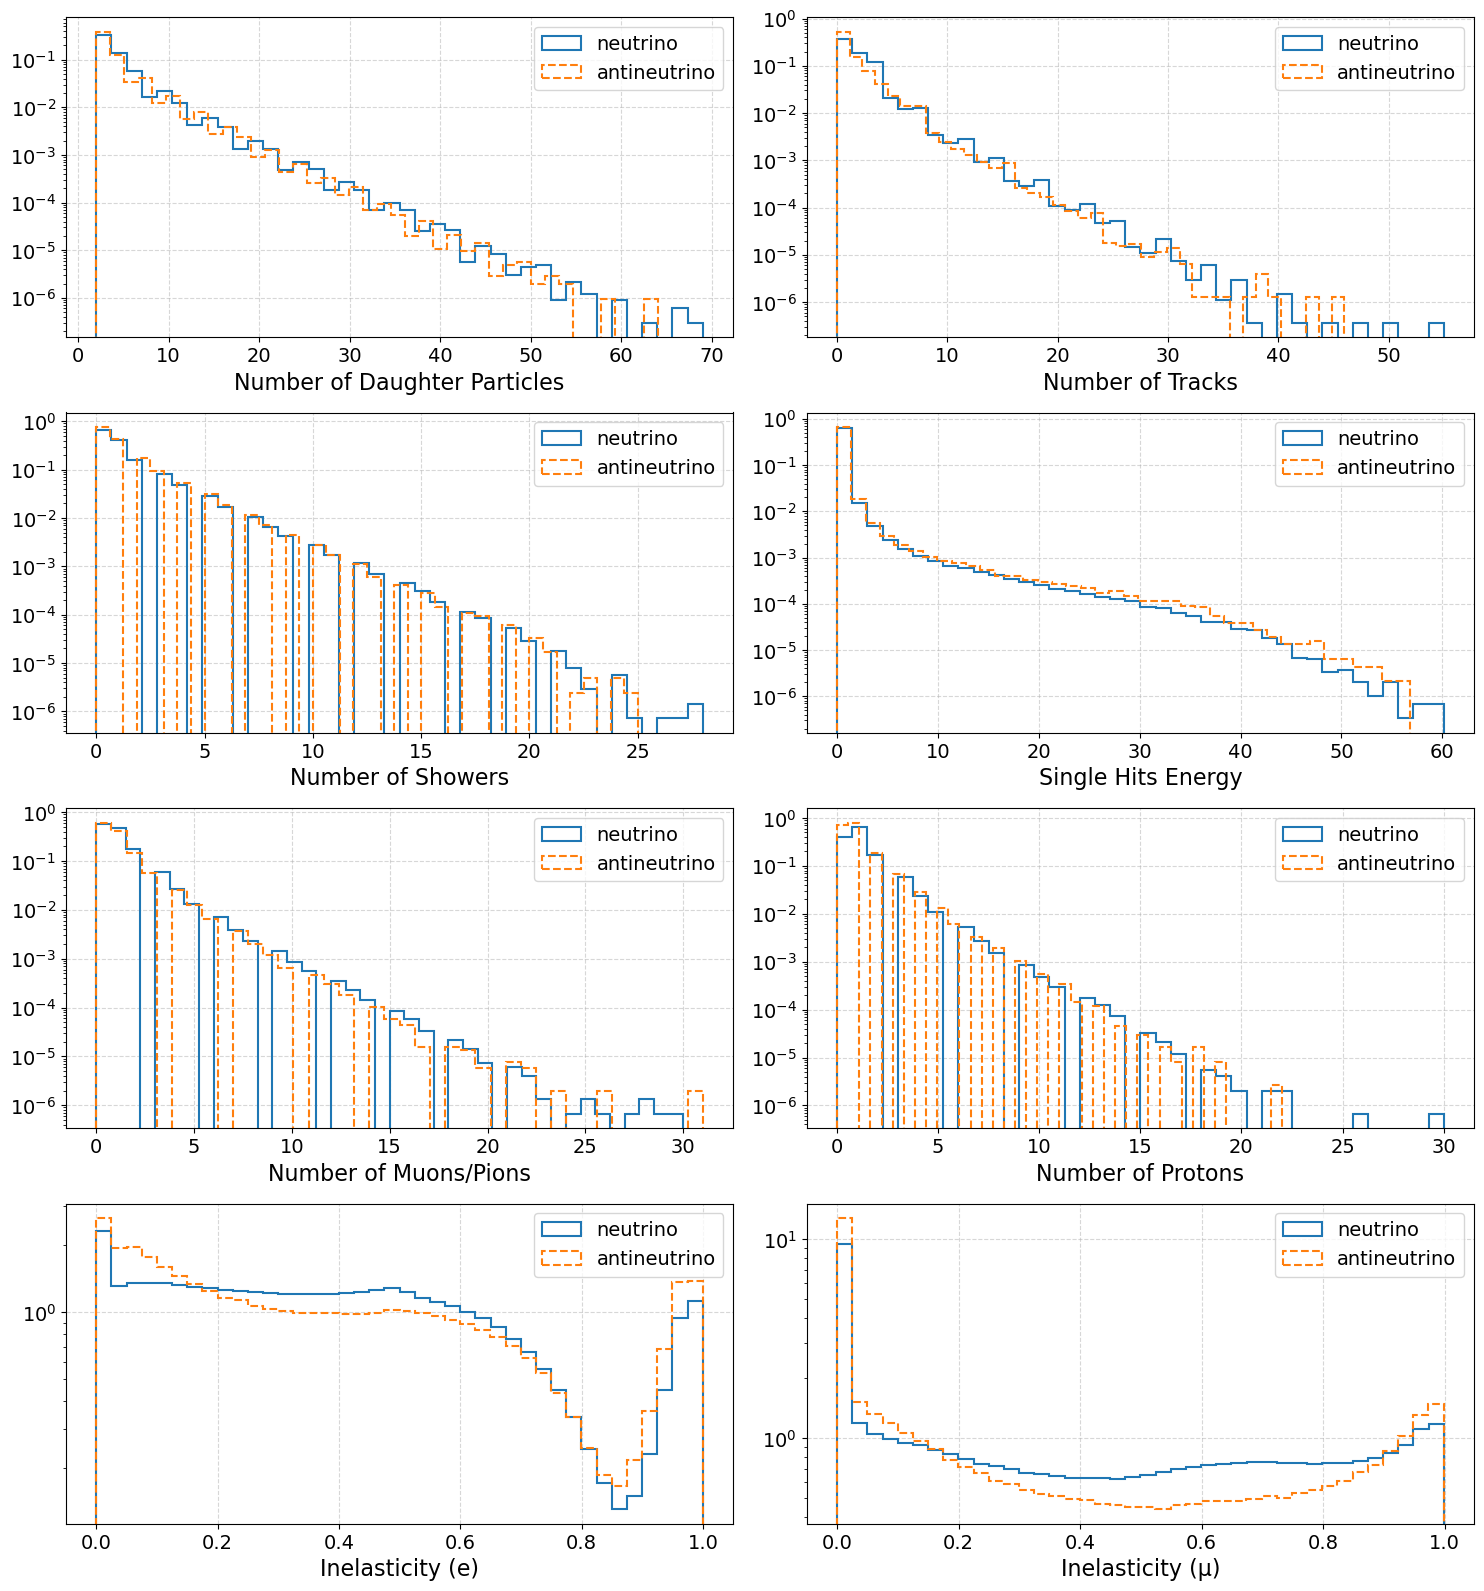

In [42]:
n_features = len(features)
n_cols = 2

n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))

def set_plot_style():
	plt.rcParams.update({
		"font.size": 12,
		"axes.labelsize": 16,
		"xtick.labelsize": 14,
		"ytick.labelsize": 14,
		"legend.fontsize": 14,
		"lines.linewidth": 1.5
	})
     
set_plot_style()

axes = axes.flatten()

for i, feat in enumerate(features):
    ax = axes[i]
    
    ax.hist(plotting_data[feat][is_nu], bins=40, density=True, histtype="step", label="neutrino", linewidth=1.5)
    ax.hist(plotting_data[feat][is_nubar], bins=40, density=True, histtype="step", label="antineutrino", linestyle="--", linewidth=1.5)
    
    ax.set_yscale("log")
    ax.set_xlabel(label_map.get(feat, feat))
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend()

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("nu_nubar_correlation_plots.pdf")
plt.show()